This code generates results for Section 3.1 Prompt-based Approaches.
Because the GPT prompts' results are not replicable, we stored our numerical results in CSV and one can jump to **[Load Results and Generate Figures and Tables](#generate-results)** to replicate figures and tables in the paper.

In [1]:
from openai import OpenAI
import random
from scipy.stats import ttest_ind_from_stats
import pandas as pd
import math
import numpy as np
import pandas as pd
import ast
from sklearn.utils import resample
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import os


client = OpenAI(api_key='xxx')#need API key to acess GPT

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
file_path = os.path.join(parent_dir, 'upworthy-archive-datasets/winner-all.csv')
df = pd.read_csv(file_path)

n_gpt = 1000

test_all_samples = df.sample(n = n_gpt, random_state=42)
test_sig_samples = df[df['p_value']<0.05].sample(n = n_gpt, random_state=42)
test_sig2_samples = df[df['p_value']<0.01].sample(n = n_gpt, random_state=42)
true_label_all = np.array(test_all_samples['higher_CTR'])
true_label_sig = np.array(test_sig_samples['higher_CTR'])
true_label_sig2 = np.array(test_sig2_samples['higher_CTR'])

## Numerical Experiments through GPT API

In [ ]:
result_gpt = []

test_combination = [
    ['gpt-3.5-turbo', 0, 0, 1],#zero-shot learning with significant samples
    ['gpt-3.5-turbo', 0, 2, 1],#in-context learning
    ['gpt-3.5-turbo', 1, 2, 1],
    ['gpt-3.5-turbo', 0, 5, 1],
    ['gpt-3.5-turbo', 1, 5, 1],
    ['gpt-4-turbo', 0, 0, 1],
    ['gpt-4-turbo', 0, 2, 1],
    ['gpt-4-turbo', 1, 2, 1],
    ['gpt-4-turbo', 0, 5, 1],
    ['gpt-4-turbo', 1, 5, 1]
]


for model_name, is_flip, n_demo, is_sig in test_combination:
    print('--------------------------')
    print('Parameter setting: ', model_name, is_flip, n_demo, is_sig)
                            
    pred_label = []

    if is_sig == 0:
        test_samples = test_all_samples
        true_label = true_label_all
    elif is_sig == 1:
        test_samples = test_sig_samples
        true_label = true_label_sig
    elif is_sig == 2:
        test_samples = test_sigg_samples
        true_label = true_label_sig2

    if n_demo > 0:
        demostration_samples = df[df['p_value']<0.05].sample(n = n_demo, random_state=12)
        conversation = [
          {"role": "system", "content": "You are presented with two headlines. Which one is catchier?"}
        ]

        for _, row in demostration_samples.iterrows():
            headline_1 = row['headline_1']
            headline_2 = row['headline_2']
            if is_flip  == 0:
                better_headline = '1' if row['higher_CTR'] == 1 else '2'
            else:
                better_headline = '2' if row['higher_CTR'] == 1 else '1'
            conversation.append({"role": "user", "content": f"Which one is catchier? \"1. {headline_1} 2. {headline_2}."})
            conversation.append({"role": "assistant", "content": f": \"{better_headline}."})
            #conversation.append({"role": "user", "content": f"Demonstration: \"1. {headline_1} 2. {headline_2}\"{better_headline}"})


    else:
        conversation = []
            
    for _, row in test_samples.iterrows():
        headline_1 = row['headline_1']
        headline_2 = row['headline_2']
        if headline_1 != headline_2:
            conversation_ask = conversation.copy()
            conversation_ask.append({"role": "user", "content": f"You are presented with two new headlines. Which one is catchier? 1. {headline_1} 2. {headline_2}. Please return either 1 or 2."})
            completion = client.chat.completions.create(
                model= model_name,
                messages = conversation_ask
            )

            #print(completion.choices[0].message)
            pred_label.append(find_first_number(str(completion.choices[0].message)))

    pred_label = np.array(pred_label)       
    valid_predictions_mask = pred_label != -1
    accur = (true_label[valid_predictions_mask] == pred_label[valid_predictions_mask]).mean()
    print('Accuracy:', accur)
    result_gpt.append((model_name, is_flip, n_demo, is_sig, pred_label, accur))

    result_gpt_df = pd.DataFrame(result_gpt, columns=['model_name', 'is_flip', 'n_demo', 
                                                                    'is_sig', 'pred_label', 'acc'])

    result_gpt_df.to_csv('prompt-results/result_gpt_prompt.csv', index=False)


<a id='generate-results'></a>
## Load Results and Generate Figures and Tables

In [2]:
result_gpt_df = pd.read_csv('prompt-results/result_gpt_prompt.csv')

if 'acc_vec' not in result_gpt_df.columns:
    result_gpt_df['acc_vec'] = None
for index, row in result_gpt_df.iterrows():
    #pred_label = np.array(pred_label)       
    if row['is_sig'] == 0:
        true_label = true_label_all
    elif row['is_sig'] == 1:
        true_label = true_label_sig
    elif row['is_sig'] == 2:
        true_label = true_label_sigg
    data = row['pred_label']
    data = data.replace('\n', ' ').replace('[', '').replace(']', '').replace("'", '')
    data_list = data.split()
    data_list = [int(num) for num in data_list]
    pred_label = np.array(data_list)
    #pred_label = np.array(row['pred_label'])
    valid_predictions_mask = np.array(pred_label) != -1
    accur = np.mean(true_label[valid_predictions_mask] == pred_label[valid_predictions_mask])
    stderr = np.sqrt(accur * (1 - accur) / np.sum(valid_predictions_mask))
    ci_lower = accur - 1.96 * stderr
    ci_upper = accur + 1.96 * stderr
    result_gpt_df.at[index, 'acc'] = accur
    result_gpt_df.at[index, 'ci_lower'] = ci_lower
    result_gpt_df.at[index, 'ci_upper'] = ci_upper
    result_gpt_df.at[index, 'acc_vec'] = np.array(true_label == pred_label).astype(int)
    

In [3]:
result_gpt_df[['model_name', 'n_demo', 'is_flip', 'acc']]

,model_name,n_demo,is_flip,acc
0,gpt-3.5-turbo,0,0,0.542000
1,gpt-3.5-turbo,2,0,0.487000
2,gpt-3.5-turbo,2,1,0.508509
3,gpt-3.5-turbo,5,0,0.513000
4,gpt-3.5-turbo,5,1,0.501002
5,gpt-4-turbo,0,0,0.572573
6,gpt-4-turbo,2,0,0.636000
7,gpt-4-turbo,2,1,0.629000
8,gpt-4-turbo,5,0,0.608000
9,gpt-4-turbo,5,1,0.618000


In [4]:
def bootstrap_ci(data, n_bootstrap=1000, ci=95, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    bootstrap_samples = np.random.choice(data, (n_bootstrap, len(data)), replace=True)
    bootstrap_means = np.mean(bootstrap_samples, axis=1)
    lower_bound = np.percentile(bootstrap_means, (100-ci)/2)
    upper_bound = np.percentile(bootstrap_means, 100 - (100-ci)/2)
    return lower_bound, upper_bound

# Apply bootstrap on acc_vec for each row and update ci_lower and ci_upper
for i, row in result_gpt_df.iterrows():
    lower, upper = bootstrap_ci(row['acc_vec'], random_state=42)
    result_gpt_df.at[i, 'ci_lower_bs'] = lower
    result_gpt_df.at[i, 'ci_upper_bs'] = upper


result_gpt_df[['model_name', 'acc', 'ci_lower_bs', 'ci_upper_bs']]

,model_name,acc,ci_lower_bs,ci_upper_bs
0,gpt-3.5-turbo,0.542000,0.511000,0.571000
1,gpt-3.5-turbo,0.487000,0.455000,0.515025
2,gpt-3.5-turbo,0.508509,0.476000,0.537000
3,gpt-3.5-turbo,0.513000,0.482000,0.543000
4,gpt-3.5-turbo,0.501002,0.468000,0.532000
5,gpt-4-turbo,0.572573,0.541975,0.600000
6,gpt-4-turbo,0.636000,0.605000,0.664000
7,gpt-4-turbo,0.629000,0.597000,0.657000
8,gpt-4-turbo,0.608000,0.577000,0.634000
9,gpt-4-turbo,0.618000,0.584975,0.648000


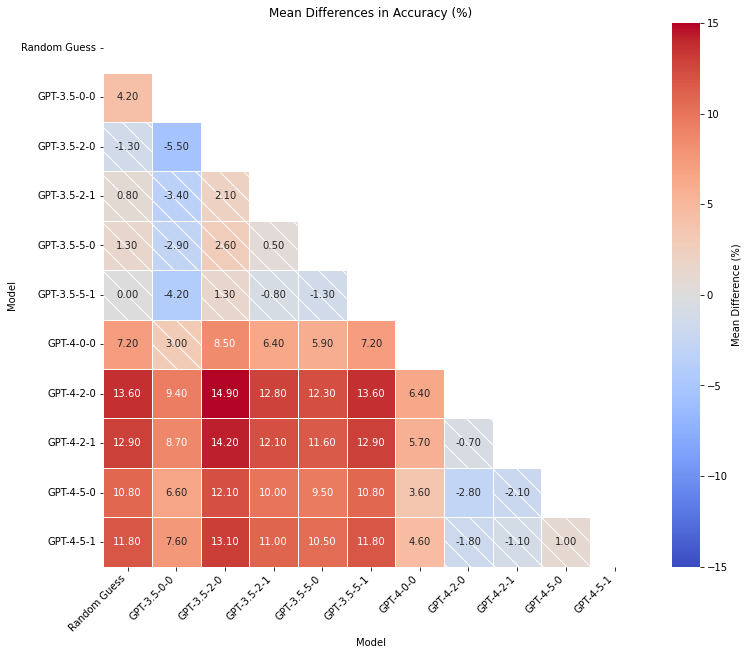

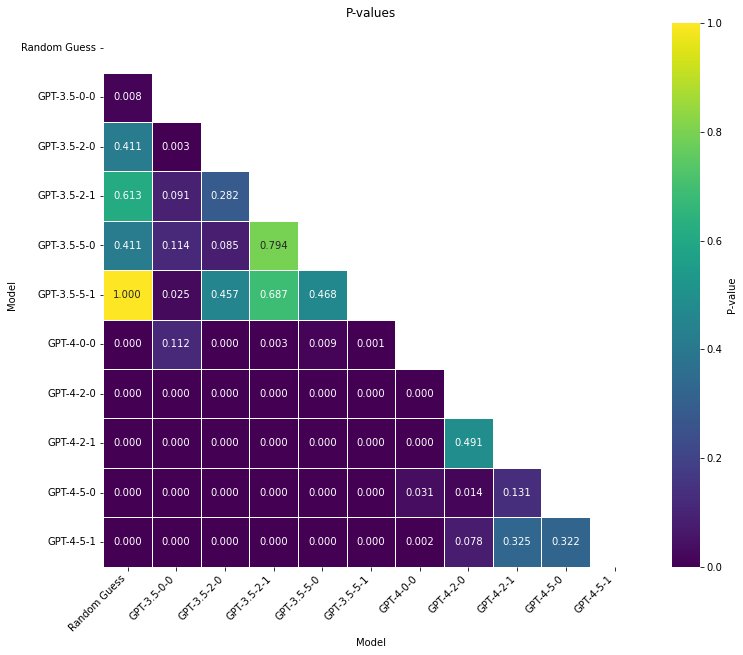

In [5]:
result_gpt_df = pd.read_csv('upworthy-archive-datasets/prompt-results/result_gpt_prompt.csv')

if 'acc_vec' not in result_gpt_df.columns:
    result_gpt_df['acc_vec'] = None
for index, row in result_gpt_df.iterrows():
    #pred_label = np.array(pred_label)       
    if row['is_sig'] == 0:
        true_label = true_label_all
    elif row['is_sig'] == 1:
        true_label = true_label_sig
    elif row['is_sig'] == 2:
        true_label = true_label_sigg
    data = row['pred_label']
    data = data.replace('\n', ' ').replace('[', '').replace(']', '').replace("'", '')
    data_list = data.split()
    data_list = [int(num) for num in data_list]
    pred_label = np.array(data_list)
    result_gpt_df.at[index, 'pred_label'] = pred_label
    valid_predictions_mask = np.array(pred_label) != -1
    accur = np.mean(true_label[valid_predictions_mask] == pred_label[valid_predictions_mask])
    stderr = np.sqrt(accur * (1 - accur) / np.sum(valid_predictions_mask))
    ci_lower = accur - 1.96 * stderr
    ci_upper = accur + 1.96 * stderr
    result_gpt_df.at[index, 'acc'] = accur
    result_gpt_df.at[index, 'ci_lower'] = ci_lower
    result_gpt_df.at[index, 'ci_upper'] = ci_upper
    result_gpt_df.at[index, 'acc_vec'] = np.array(true_label == pred_label).astype(int)
    
    
model_list = [
    "GPT-3.5-0-0",
    "GPT-3.5-2-0",
    "GPT-3.5-2-1",
    "GPT-3.5-5-0",
    "GPT-3.5-5-1",
    "GPT-4-0-0",
    "GPT-4-2-0",
    "GPT-4-2-1",
    "GPT-4-5-0",
    "GPT-4-5-1"
]
mean_list = np.array(result_gpt_df['acc'])
mean_diff_matrix = np.zeros((len(model_list) + 1, len(model_list) + 1))
pval_matrix = np.zeros((len(model_list) + 1, len(model_list) + 1))

# Append "random guess" model to the list
model_list.append("Random Guess")


for i in range(len(model_list) - 1):  # Exclude "random guess" in this loop
    for j in range(len(model_list) - 1):  # Exclude "random guess" in this loop
        rvs1 = (np.array(result_gpt_df['pred_label'])[i] == true_label_sig).astype(int)
        rvs2 = (np.array(result_gpt_df['pred_label'])[j] == true_label_sig).astype(int)
        stat, pval = stats.ttest_rel(rvs1, rvs2)

        # Store mean difference and p-value
        mean_diff_matrix[i, j] = (rvs1.mean() - rvs2.mean()) * 100
        pval_matrix[i, j] = pval

# Compare each model with "random guess"
for i in range(len(model_list) - 1):
    rvs = (np.array(result_gpt_df['pred_label'])[i] == true_label_sig).astype(int)
    mean_diff = (rvs.mean() - 0.5) * 100
    stat, pval = stats.ttest_1samp(rvs, 0.5)

    # Store mean difference and p-value
    mean_diff_matrix[i, len(model_list) - 1] = mean_diff
    mean_diff_matrix[len(model_list) - 1, i] = -mean_diff
    pval_matrix[i, len(model_list) - 1] = pval
    pval_matrix[len(model_list) - 1, i] = pval

# Store the "random guess" model's self-comparison (diagonal)
mean_diff_matrix[len(model_list) - 1, len(model_list) - 1] = 0
pval_matrix[len(model_list) - 1, len(model_list) - 1] = 1

# Move "random guess" to the first place
model_list = ["Random Guess"] + model_list[:-1]
mean_diff_matrix = np.vstack([mean_diff_matrix[-1], mean_diff_matrix[:-1]])
mean_diff_matrix = np.hstack([mean_diff_matrix[:, -1].reshape(-1, 1), mean_diff_matrix[:, :-1]])
pval_matrix = np.vstack([pval_matrix[-1], pval_matrix[:-1]])
pval_matrix = np.hstack([pval_matrix[:, -1].reshape(-1, 1), pval_matrix[:, :-1]])

mean_diff_df = pd.DataFrame(mean_diff_matrix, index=model_list, columns=model_list)
pval_df = pd.DataFrame(pval_matrix, index=model_list, columns=model_list)

mask_pval = pval_df >= 0.05

# Create a mask to hide the upper triangle and the diagonal
upper_triangle_mask = np.triu(np.ones_like(mean_diff_matrix, dtype=bool))
np.fill_diagonal(upper_triangle_mask, True)

# Combined mask to hide upper triangle and non-significant p-values
combined_mask = mask_pval | upper_triangle_mask

# Create a cross-style mask for p-values greater than or equal to 0.05
cross_mask = np.zeros_like(mean_diff_matrix, dtype=bool)
cross_mask[mask_pval & ~upper_triangle_mask] = True

# Plot the heatmap of mean differences with the combined mask applied
plt.figure(figsize=(12, 10))
ax = sns.heatmap(mean_diff_df, mask=upper_triangle_mask, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'Mean Difference (%)'},
                  linewidths=.5, linecolor='white', vmin=-15, vmax=15, center=0)

# Apply cross-style mask
for i in range(len(model_list)):
    for j in range(len(model_list)):
        if cross_mask[i, j]:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='white', lw=1, hatch='\\'))

plt.title('Mean Differences in Accuracy (%)')
plt.xlabel('Model')
plt.ylabel('Model')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.savefig("prompt-results/mean_differences_heatmap.pdf", format='pdf', bbox_inches='tight')
plt.show()

# Create a mask to hide the upper triangle for the p-value heatmap
lower_triangle_mask = np.tril(np.ones_like(pval_df, dtype=bool), -1)

# Plot the heatmap of p-values with the lower triangle mask applied
plt.figure(figsize=(12, 10))
sns.heatmap(pval_df, mask=~lower_triangle_mask, annot=True, fmt=".3f", cmap="viridis", cbar_kws={'label': 'P-value'}, linewidths=.5, linecolor='white')
plt.title('P-values')
plt.xlabel('Model')
plt.ylabel('Model')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.savefig("prompt-results/p_values_heatmap.pdf", format='pdf', bbox_inches='tight')
plt.show()